Step 4.1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 4.2 — Load original dataset

In [2]:
df = pd.read_csv("../data/raw/financial_fraud_detection_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 14)


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


Step 4.3 — Check original columns

In [3]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
Transaction_ID
Customer_ID
Transaction_Date
Transaction_Amount
Merchant_Category
Payment_Method
Device_Type
Location
Is_International
Previous_Transactions
Average_Spend
Account_Age_Days
Suspicious_Keyword
Fraudulent


Step 4.4 — Convert transaction date

In [4]:
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="%d-%m-%Y %H:%M"
)

print(df["Transaction_Date"].head())

0   2023-10-04 07:45:00
1   2023-09-26 08:29:00
2   2023-07-18 15:54:00
3   2023-10-16 17:10:00
4   2023-09-09 00:46:00
Name: Transaction_Date, dtype: datetime64[us]


Step 4.5 — Create transaction time features

In [5]:
df["Transaction_Hour"] = df["Transaction_Date"].dt.hour
df["Transaction_Day"] = df["Transaction_Date"].dt.day
df["Transaction_Month"] = df["Transaction_Date"].dt.month

df[
    [
        "Transaction_Date",
        "Transaction_Hour",
        "Transaction_Day",
        "Transaction_Month"
    ]
].head()

,Transaction_Date,Transaction_Hour,Transaction_Day,Transaction_Month
0,2023-10-04 07:45:00,7,4,10
1,2023-09-26 08:29:00,8,26,9
2,2023-07-18 15:54:00,15,18,7
3,2023-10-16 17:10:00,17,16,10
4,2023-09-09 00:46:00,0,9,9


Step 4.6 — Create amount deviation feature

In [6]:
df["Amount_Deviation"] = (
    df["Transaction_Amount"] /
    df["Average_Spend"].replace(0, np.nan)
)

df["Amount_Deviation"] = df["Amount_Deviation"].fillna(0)

df[
    [
        "Transaction_Amount",
        "Average_Spend",
        "Amount_Deviation"
    ]
].head()

,Transaction_Amount,Average_Spend,Amount_Deviation
0,37.54,417.40,0.089938
1,240.81,335.47,0.717829
2,105.34,432.03,0.243826
3,73.04,488.30,0.149580
4,13.57,437.03,0.031050


Step 4.7 — Create high amount flag

In [7]:
df["High_Amount_Flag"] = (
    df["Transaction_Amount"] >
    df["Average_Spend"] * 2
).astype(int)

df["High_Amount_Flag"].value_counts()

High_Amount_Flag
0    4717
1     283
Name: count, dtype: int64

Step 4.8 — Create account age in years

In [8]:
df["Account_Age_Years"] = (
    df["Account_Age_Days"] / 365
)

df[
    [
        "Account_Age_Days",
        "Account_Age_Years"
    ]
].head()

,Account_Age_Days,Account_Age_Years
0,1492,4.087671
1,66,0.180822
2,216,0.591781
3,449,1.230137
4,754,2.065753


Step 4.9 — Create transaction frequency proxy

In [9]:
df["Transactions_Per_Account_Year"] = (
    df["Previous_Transactions"] /
    (df["Account_Age_Years"] + 1)
)

df[
    [
        "Previous_Transactions",
        "Account_Age_Years",
        "Transactions_Per_Account_Year"
    ]
].head()

,Previous_Transactions,Account_Age_Years,Transactions_Per_Account_Year
0,94,4.087671,18.476037
1,76,0.180822,64.361949
2,60,0.591781,37.693632
3,68,1.230137,30.491400
4,57,2.065753,18.592493


Step 4.10 — Check new features

In [10]:
new_features = [
    "Transaction_Hour",
    "Transaction_Day",
    "Transaction_Month",
    "Amount_Deviation",
    "High_Amount_Flag",
    "Account_Age_Years",
    "Transactions_Per_Account_Year"
]

df[new_features].describe()

,Transaction_Hour,Transaction_Day,Transaction_Month,Amount_Deviation,High_Amount_Flag,Account_Age_Years,Transactions_Per_Account_Year
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,11.548200,15.39200,5.952400,0.588936,0.0566,2.770296,33.031300
std,6.891413,8.78757,3.643458,1.285842,0.2311,1.557901,27.896937
min,0.000000,1.00000,1.000000,0.000000,0.0000,0.082192,0.156585
25%,6.000000,8.00000,2.000000,0.091337,0.0000,1.452055,13.602138
50%,12.000000,15.00000,6.000000,0.241066,0.0000,2.773973,26.380076
75%,17.000000,23.00000,9.000000,0.576681,0.0000,4.098630,42.950336
max,23.000000,31.00000,12.000000,28.363287,1.0000,5.476712,182.500000


Step 4.11 — Check relationship with fraud

In [11]:
for feature in new_features:
    print("\n", feature)
    print(
        df.groupby("Fraudulent")[feature].mean()
    )


 Transaction_Hour
Fraudulent
0    12.076583
1     6.595436
Name: Transaction_Hour, dtype: float64

 Transaction_Day
Fraudulent
0    15.447322
1    14.873444
Name: Transaction_Day, dtype: float64

 Transaction_Month
Fraudulent
0    5.949314
1    5.981328
Name: Transaction_Month, dtype: float64

 Amount_Deviation
Fraudulent
0    0.578684
1    0.685038
Name: Amount_Deviation, dtype: float64

 High_Amount_Flag
Fraudulent
0    0.055556
1    0.066390
Name: High_Amount_Flag, dtype: float64

 Account_Age_Years
Fraudulent
0    2.765940
1    2.811135
Name: Account_Age_Years, dtype: float64

 Transactions_Per_Account_Year
Fraudulent
0    33.101567
1    32.372659
Name: Transactions_Per_Account_Year, dtype: float64


Step 4.12 — Amount Deviation visualization

<Figure size 800x500 with 0 Axes>

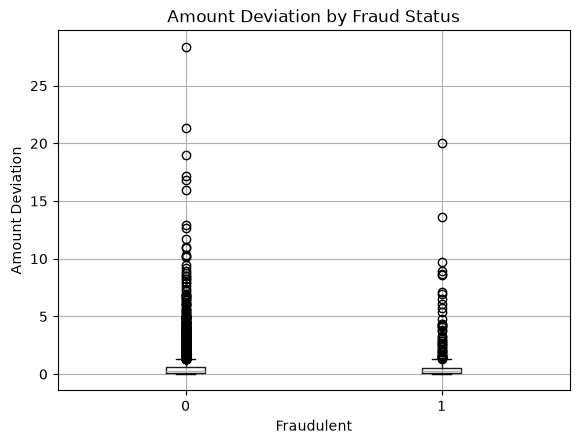

In [12]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Amount_Deviation",
    by="Fraudulent"
)

plt.title("Amount Deviation by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraudulent")
plt.ylabel("Amount Deviation")

plt.show()

Step 4.13 — High Amount Flag vs Fraud

In [13]:
fraud_rate_high_amount = (
    df.groupby("High_Amount_Flag")["Fraudulent"]
    .mean() * 100
)

print(fraud_rate_high_amount)

High_Amount_Flag
0     9.539962
1    11.307420
Name: Fraudulent, dtype: float64


Step 4.14 — Save engineered dataset

In [14]:
df.to_csv(
    "../data/processed/financial_fraud_feature_engineered.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.
